# 📖 Terminologia de Grafos

**Conceitos fundamentais:** Vértices adjacentes, arestas incidentes, laços, arestas paralelas, vértices isolados e subgrafos.

---

In [1]:
# Importando bibliotecas
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
%matplotlib inline

## 1. Conceitos Básicos de Terminologia

### 📌 Definições:

- **Arestas incidentes a um vértice**: Arestas que tocam/conectam um vértice
- **Vértices adjacentes**: Dois vértices conectados por uma aresta
- **Arestas adjacentes**: Duas arestas que compartilham um vértice em comum
- **Laço (loop)**: Uma aresta que conecta um vértice a ele mesmo
- **Arestas paralelas**: Duas ou mais arestas conectando o mesmo par de vértices
- **Vértice isolado**: Um vértice sem nenhuma aresta incidente

---

## 2. Exemplo Completo: Grafo com Terminologia

Vamos criar um grafo que demonstra todos os conceitos:

- Vértices: $\{v_1, v_2, v_3, v_4, v_5, v_6\}$
- Arestas: $\{e_1, e_2, e_3, e_4, e_5, e_6, e_7\}$

In [2]:
# Criando um multigrafo (permite arestas paralelas e laços)
G = nx.MultiGraph()

# Adicionando vértices
vertices = ['v1', 'v2', 'v3', 'v4', 'v5', 'v6']
G.add_nodes_from(vertices)

# Adicionando arestas com rótulos
arestas = [
    ('v1', 'v2', {'label': 'e1'}),
    ('v1', 'v3', {'label': 'e2'}),
    ('v1', 'v3', {'label': 'e3'}),  # Aresta paralela a e2
    ('v2', 'v3', {'label': 'e4'}),
    ('v5', 'v6', {'label': 'e5'}),
    ('v5', 'v5', {'label': 'e6'}),  # Laço em v5
    ('v6', 'v6', {'label': 'e7'}),  # Laço em v6
]

for u, v, attr in arestas:
    G.add_edge(u, v, **attr)

print("Conjunto de vértices V:", list(G.nodes()))
print(f"\nTotal de vértices: {G.number_of_nodes()}")
print(f"Total de arestas: {G.number_of_edges()}")

Conjunto de vértices V: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6']

Total de vértices: 6
Total de arestas: 7


In [3]:
# Função aresta-vértice (tabela)
print("\nFunção Aresta-Vértice:")
print("-" * 30)
print(f"{'Aresta':<10} | {'Vértices'}")
print("-" * 30)

aresta_vertice = {
    'e1': '{v1, v2}',
    'e2': '{v1, v3}',
    'e3': '{v1, v3}',
    'e4': '{v2, v3}',
    'e5': '{v5, v6}',
    'e6': '{v5}',      # Laço
    'e7': '{v6}',      # Laço
}

for aresta, verts in aresta_vertice.items():
    print(f"{aresta:<10} | {verts}")


Função Aresta-Vértice:
------------------------------
Aresta     | Vértices
------------------------------
e1         | {v1, v2}
e2         | {v1, v3}
e3         | {v1, v3}
e4         | {v2, v3}
e5         | {v5, v6}
e6         | {v5}
e7         | {v6}


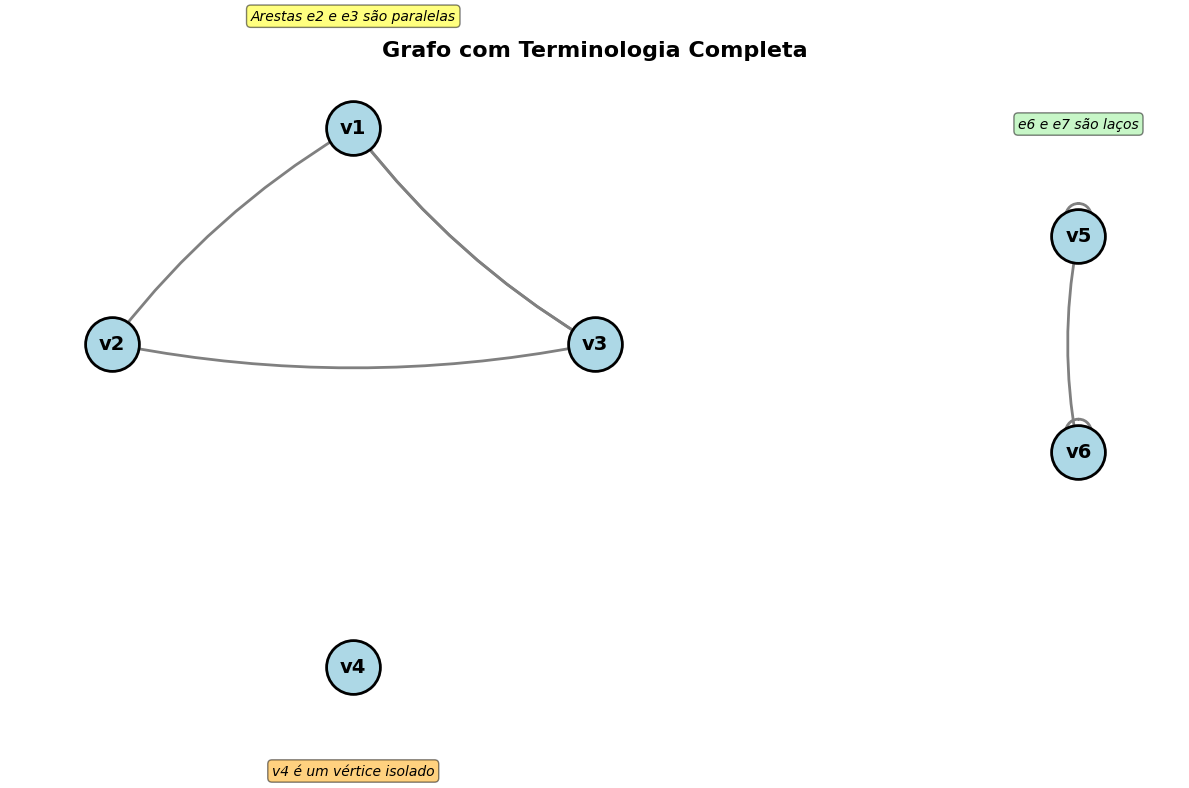

In [4]:
# Visualização do grafo
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True, constrained_layout=True)

# Layout manual para melhor visualização
pos = {
    'v1': (0, 1),
    'v2': (-1, 0),
    'v3': (1, 0),
    'v4': (0, -1.5),    # Isolado
    'v5': (3, 0.5),
    'v6': (3, -0.5)
}

# Desenhando vértices
nx.draw_networkx_nodes(G, pos, 
                       node_color='lightblue', 
                       node_size=1500,
                       edgecolors='black',
                       linewidths=2)

# Desenhando rótulos dos vértices
nx.draw_networkx_labels(G, pos, 
                        font_size=14, 
                        font_weight='bold')

# Desenhando arestas
nx.draw_networkx_edges(G, pos, 
                       edge_color='gray', 
                       width=2,
                       connectionstyle='arc3,rad=0.1', ax=ax)

ax.set_title('Grafo com Terminologia Completa', fontsize=16, fontweight='bold', pad=20)
plt.axis('off')

# Anotações
plt.text(0, 1.5, 'Arestas e2 e e3 são paralelas', 
         ha='center', fontsize=10, style='italic', 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
plt.text(0, -2, 'v4 é um vértice isolado', 
         ha='center', fontsize=10, style='italic',
         bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))
plt.text(3, 1, 'e6 e e7 são laços', 
         ha='center', fontsize=10, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
plt.show()

---

## 3. Análise de Relações

### Relações no grafo acima:

In [5]:
# Analisando relações
print("📊 ANÁLISE DE RELAÇÕES:\n")

# 1. Arestas incidentes a v1
print("1️⃣ Arestas incidentes a v1:")
print("   e1, e2 e e3 são incidentes a v1")
print(f"   (v1 tem {G.degree('v1')} arestas incidentes)\n")

# 2. Vértices adjacentes a v1
print("2️⃣ Vértices adjacentes a v1:")
vizinhos_v1 = list(G.neighbors('v1'))
print(f"   {vizinhos_v1}\n")

# 3. Arestas adjacentes a e1
print("3️⃣ Arestas adjacentes a e1:")
print("   e2, e3 e e4 são adjacentes a e1")
print("   (compartilham vértices v1 ou v2)\n")

# 4. Laços
print("4️⃣ Laços:")
print("   e6 é um laço em v5")
print("   e7 é um laço em v6\n")

# 5. Arestas paralelas
print("5️⃣ Arestas paralelas:")
print("   e2 e e3 são paralelas (ambas conectam v1 e v3)\n")

# 6. Vértices adjacentes
print("6️⃣ Vértices adjacentes entre si:")
print("   v5 e v6 são adjacentes\n")

# 7. Vértice isolado
print("7️⃣ Vértice isolado:")
print("   v4 é um vértice isolado (grau 0)")
print(f"   Grau de v4: {G.degree('v4')}")

📊 ANÁLISE DE RELAÇÕES:

1️⃣ Arestas incidentes a v1:
   e1, e2 e e3 são incidentes a v1
   (v1 tem 3 arestas incidentes)

2️⃣ Vértices adjacentes a v1:
   ['v2', 'v3']

3️⃣ Arestas adjacentes a e1:
   e2, e3 e e4 são adjacentes a e1
   (compartilham vértices v1 ou v2)

4️⃣ Laços:
   e6 é um laço em v5
   e7 é um laço em v6

5️⃣ Arestas paralelas:
   e2 e e3 são paralelas (ambas conectam v1 e v3)

6️⃣ Vértices adjacentes entre si:
   v5 e v6 são adjacentes

7️⃣ Vértice isolado:
   v4 é um vértice isolado (grau 0)
   Grau de v4: 0


---

## 4. Exemplo: Duas Representações do Mesmo Grafo

Um mesmo grafo pode ser desenhado de formas diferentes, mas continua sendo o mesmo grafo logicamente.

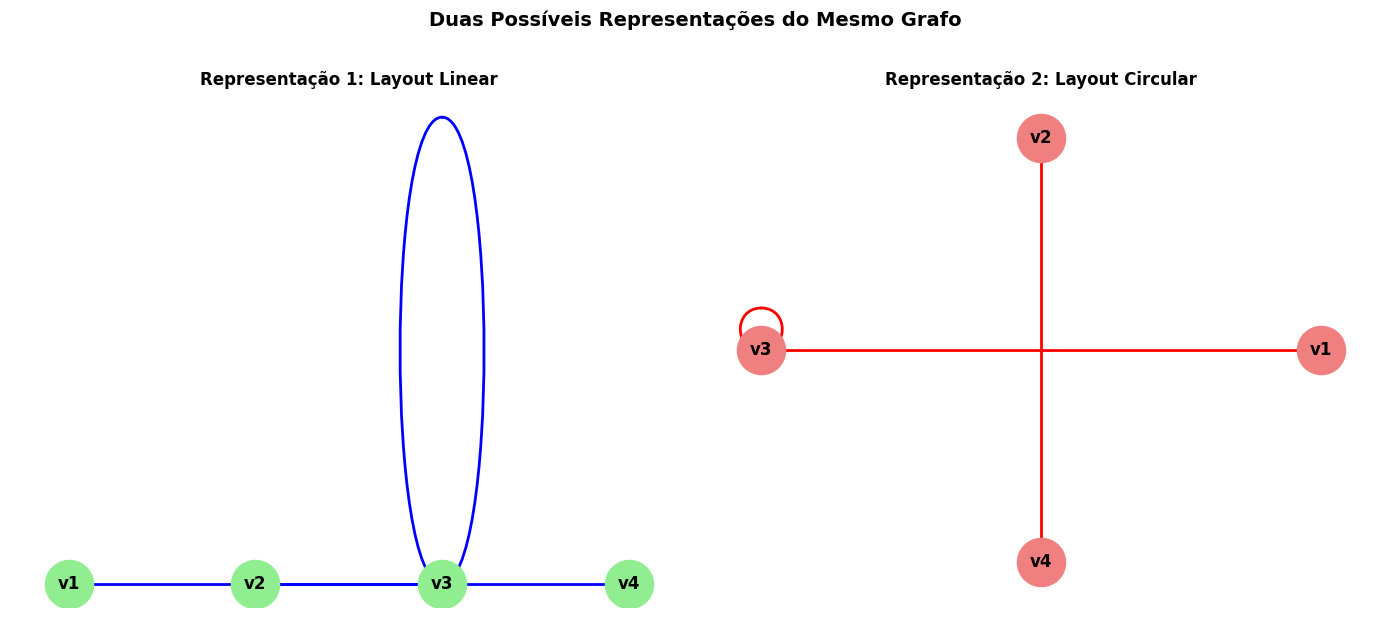

Ambos os grafos possuem:
Vértices: ['v1', 'v2', 'v3', 'v4']
Arestas: [('v1', 'v3'), ('v2', 'v4'), ('v3', 'v3')]


In [6]:
# Criando um grafo para demonstrar diferentes representações
G_rep = nx.Graph()

# Vértices e arestas
G_rep.add_nodes_from(['v1', 'v2', 'v3', 'v4'])
G_rep.add_edges_from([('v1', 'v3'), ('v2', 'v4'), ('v2', 'v4'), ('v3', 'v3')])

# Duas representações visuais diferentes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Representação 1: Layout em linha
pos1 = {'v1': (0, 0), 'v2': (1, 0), 'v3': (2, 0), 'v4': (3, 0)}
nx.draw(G_rep, pos1, ax=ax1,
        with_labels=True,
        node_color='lightgreen',
        node_size=1200,
        font_size=12,
        font_weight='bold',
        edge_color='blue',
        width=2)
ax1.set_title('Representação 1: Layout Linear', fontsize=12, fontweight='bold')
ax1.axis('off')

# Representação 2: Layout em círculo
pos2 = nx.circular_layout(G_rep)
nx.draw(G_rep, pos2, ax=ax2,
        with_labels=True,
        node_color='lightcoral',
        node_size=1200,
        font_size=12,
        font_weight='bold',
        edge_color='red',
        width=2)
ax2.set_title('Representação 2: Layout Circular', fontsize=12, fontweight='bold')
ax2.axis('off')

plt.suptitle('Duas Possíveis Representações do Mesmo Grafo', 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("Ambos os grafos possuem:")
print(f"Vértices: {list(G_rep.nodes())}")
print(f"Arestas: {list(G_rep.edges())}")

---

## 5. Identificação de Vértices e Rótulos

### Exemplo: Pentágono (C₅)

In [7]:
# Criando um grafo ciclo com 5 vértices (pentágono)
pentagono = nx.cycle_graph(5)

# Renomeando vértices
mapping = {0: 'v1', 1: 'v2', 2: 'v3', 3: 'v4', 4: 'v5'}
pentagono = nx.relabel_nodes(pentagono, mapping)

print("Grafo Pentágono (C₅)")
print(f"Vértices: {list(pentagono.nodes())}")
print(f"Arestas: {list(pentagono.edges())}")
print("\nFunção aresta-vértice:")
print("-" * 30)

arestas_pentagono = {
    'e1': '{v1, v2}',
    'e2': '{v2, v3}',
    'e3': '{v3, v4}',
    'e4': '{v4, v5}',
    'e5': '{v5, v1}'
}

for aresta, verts in arestas_pentagono.items():
    print(f"{aresta}: {verts}")

Grafo Pentágono (C₅)
Vértices: ['v1', 'v2', 'v3', 'v4', 'v5']
Arestas: [('v1', 'v2'), ('v1', 'v5'), ('v2', 'v3'), ('v3', 'v4'), ('v4', 'v5')]

Função aresta-vértice:
------------------------------
e1: {v1, v2}
e2: {v2, v3}
e3: {v3, v4}
e4: {v4, v5}
e5: {v5, v1}


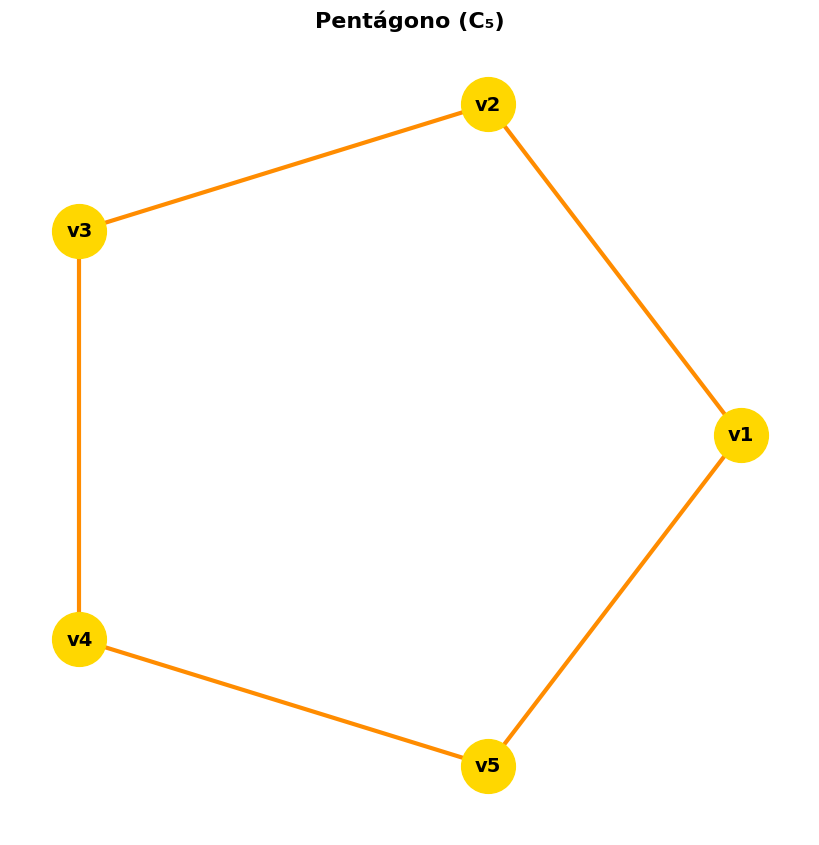

In [8]:
# Visualização do pentágono
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True, constrained_layout=True)
pos = nx.circular_layout(pentagono)
nx.draw(pentagono, pos,
        with_labels=True,
        node_color='gold',
        node_size=1500,
        font_size=14,
        font_weight='bold',
        edge_color='darkorange',
        width=3, ax=ax)
ax.set_title('Pentágono (C₅)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

---

## 6. Subgrafos

### 📚 Definição:

Um grafo $H = (V', E')$ é um **subgrafo** de $G = (V, E)$ se e somente se:

1. Cada vértice de $H$ é também um vértice de $G$: $V' \subseteq V$
2. Cada aresta de $H$ é também uma aresta de $G$: $E' \subseteq E$
3. Cada aresta de $H$ tem os mesmos nós terminais em $G$

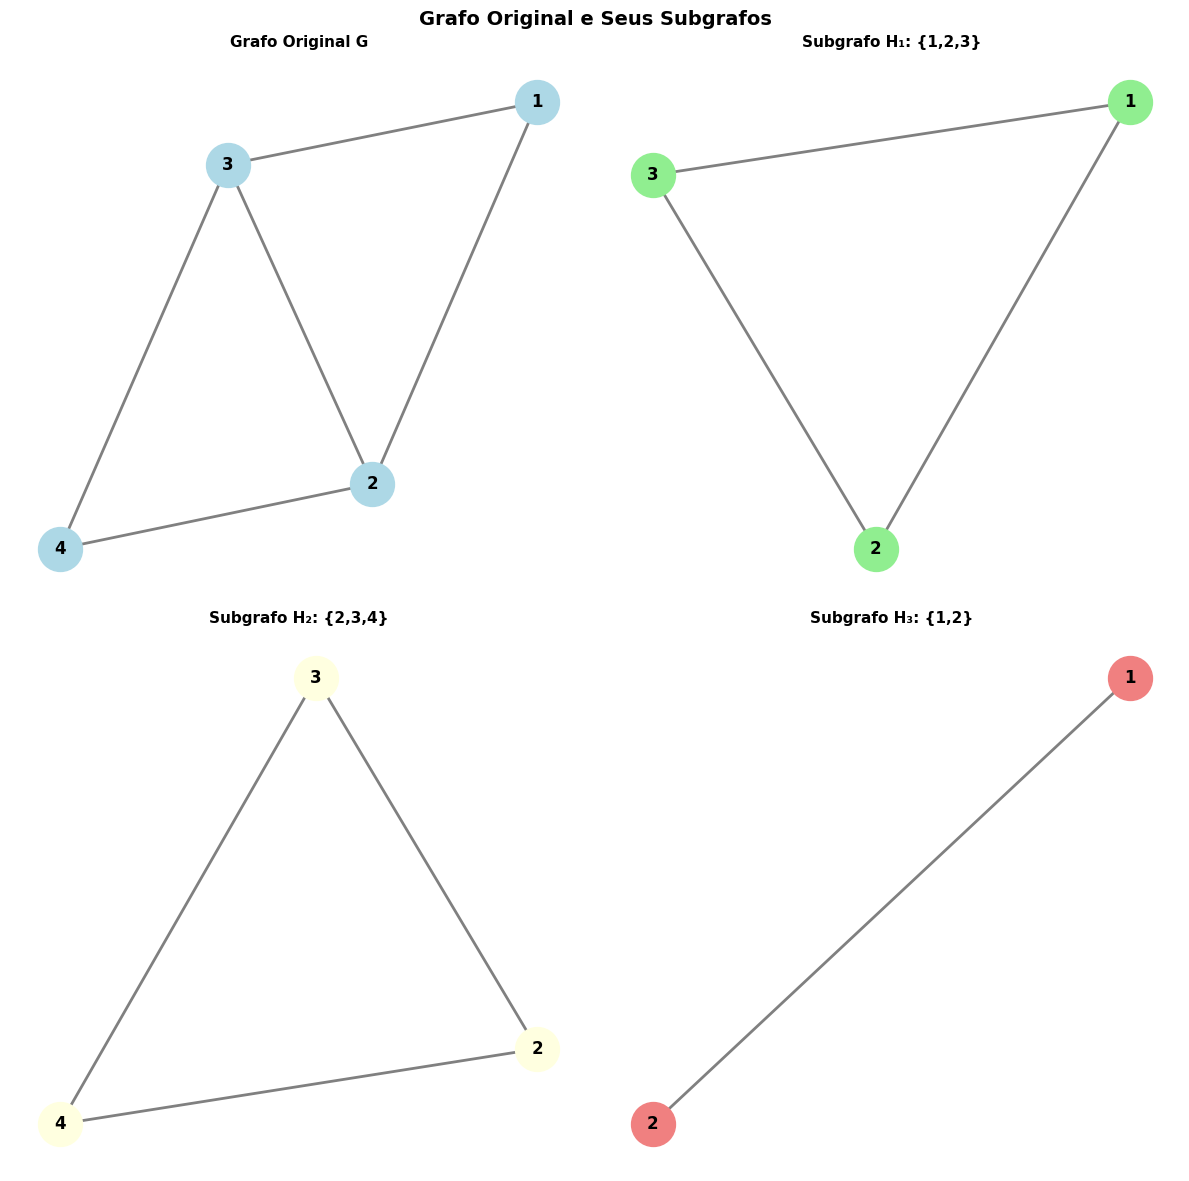

Verificação de subgrafos:
H₁ é subgrafo de G: True
H₂ é subgrafo de G: True
H₃ é subgrafo de G: True


In [9]:
# Criando um grafo original
G_original = nx.Graph()
G_original.add_edges_from([(1, 2), (1, 3), (2, 3), (2, 4), (3, 4)])

# Criando subgrafos
subgrafo1 = G_original.subgraph([1, 2, 3])
subgrafo2 = G_original.subgraph([2, 3, 4])
subgrafo3 = G_original.subgraph([1, 2])

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

grafos = [G_original, subgrafo1, subgrafo2, subgrafo3]
titulos = ['Grafo Original G', 'Subgrafo H₁: {1,2,3}', 'Subgrafo H₂: {2,3,4}', 'Subgrafo H₃: {1,2}']
cores = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']

pos_original = nx.spring_layout(G_original, seed=42)

for i, (g, titulo, cor) in enumerate(zip(grafos, titulos, cores)):
    ax = axes[i // 2, i % 2]
    
    # Usar mesma posição para todos os grafos
    pos_atual = {n: pos_original[n] for n in g.nodes()}
    
    nx.draw(g, pos_atual, ax=ax,
            with_labels=True,
            node_color=cor,
            node_size=1000,
            font_size=12,
            font_weight='bold',
            edge_color='gray',
            width=2)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Grafo Original e Seus Subgrafos', fontsize=14, fontweight='bold', y=0.98)
plt.show()

print("Verificação de subgrafos:")
print(f"H₁ é subgrafo de G: {set(subgrafo1.nodes()).issubset(set(G_original.nodes()))}")
print(f"H₂ é subgrafo de G: {set(subgrafo2.nodes()).issubset(set(G_original.nodes()))}")
print(f"H₃ é subgrafo de G: {set(subgrafo3.nodes()).issubset(set(G_original.nodes()))}")

---

## 7. Exercícios Práticos

🎯 EXERCÍCIO 1: Analise o grafo abaixo



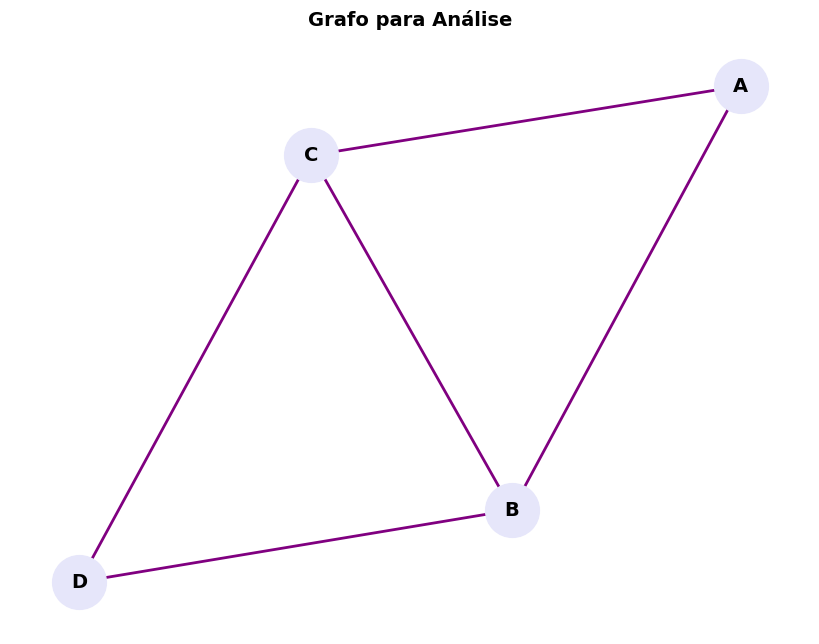

Perguntas:
1. Quais vértices são adjacentes a A?
2. Quantas arestas são incidentes a B?
3. Quais vértices são adjacentes entre si?
4. Este grafo possui laços?
5. Este grafo possui vértices isolados?

RESPOSTAS:
1. Adjacentes a A: ['B', 'C']
2. Arestas incidentes a B: 3
3. Todos os pares adjacentes: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'D')]
4. Laços: Não (grafo simples)
5. Vértices isolados: Não (todos têm grau > 0)


In [10]:
# Exercício 1: Identificar elementos do grafo
print("🎯 EXERCÍCIO 1: Analise o grafo abaixo\n")

G_exerc = nx.Graph()
G_exerc.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'D')])

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True, constrained_layout=True)
pos = nx.spring_layout(G_exerc, seed=42)
nx.draw(G_exerc, pos,
        with_labels=True,
        node_color='lavender',
        node_size=1500,
        font_size=14,
        font_weight='bold',
        edge_color='purple',
        width=2, ax=ax)
ax.set_title('Grafo para Análise', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print("Perguntas:")
print("1. Quais vértices são adjacentes a A?")
print("2. Quantas arestas são incidentes a B?")
print("3. Quais vértices são adjacentes entre si?")
print("4. Este grafo possui laços?")
print("5. Este grafo possui vértices isolados?")

print("\n" + "="*50)
print("RESPOSTAS:")
print("="*50)
print(f"1. Adjacentes a A: {list(G_exerc.neighbors('A'))}")
print(f"2. Arestas incidentes a B: {G_exerc.degree('B')}")
print(f"3. Todos os pares adjacentes: {list(G_exerc.edges())}")
print(f"4. Laços: Não (grafo simples)")
print(f"5. Vértices isolados: Não (todos têm grau > 0)")

---

## 📌 Resumo

Neste notebook, aprendemos:

1. ✅ **Terminologia básica**: Incidência, adjacência, laços, arestas paralelas
2. ✅ **Vértices isolados**: Vértices sem arestas (grau 0)
3. ✅ **Representações**: Diferentes formas visuais do mesmo grafo
4. ✅ **Subgrafos**: Grafos contidos em outros grafos
5. ✅ **Multigrafos**: Grafos com arestas paralelas e laços

### 🎯 Próximo notebook:
**03_tipos_grafos.ipynb** - Tipos específicos de grafos (simples, dirigido, completo, ciclo, roda)